In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
jobs = pd.read_csv("../data/processed/jobs_clean.csv")
skills = pd.read_csv("../data/processed/skills_clean.csv")

df = jobs.merge(skills, on="job_id")

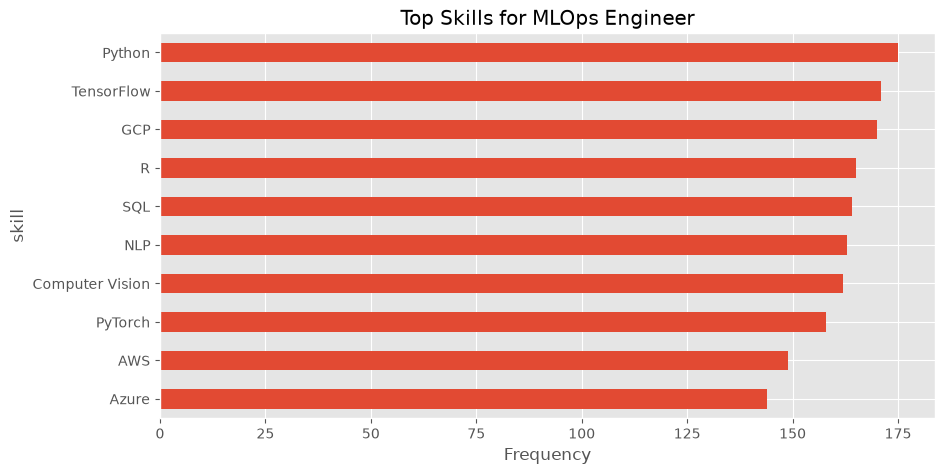

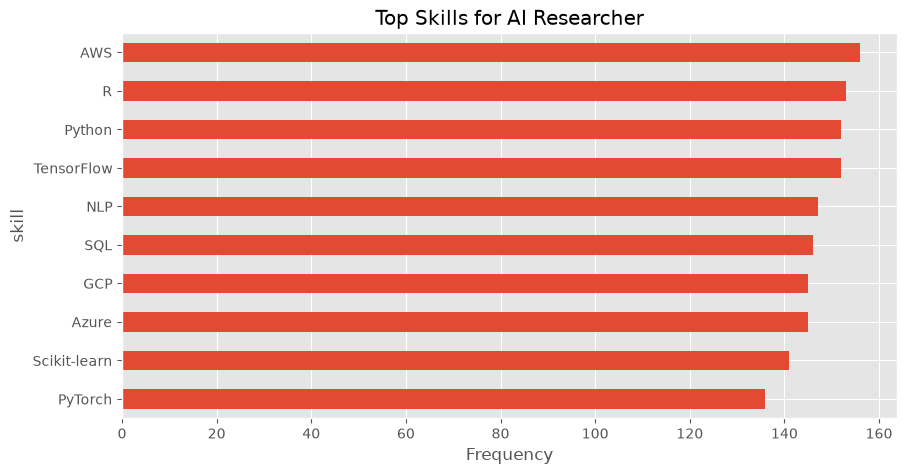

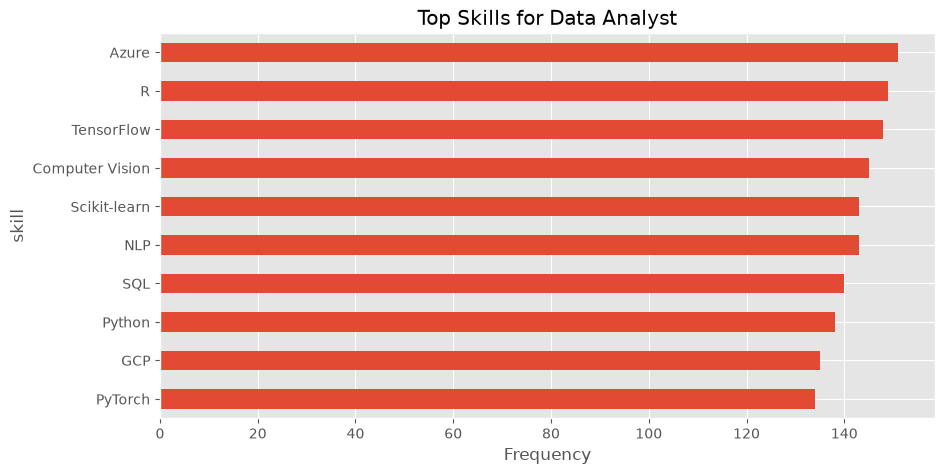

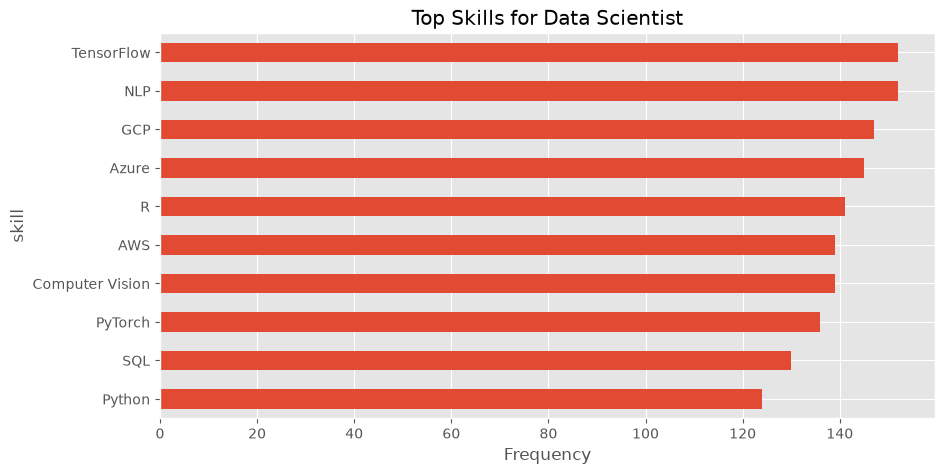

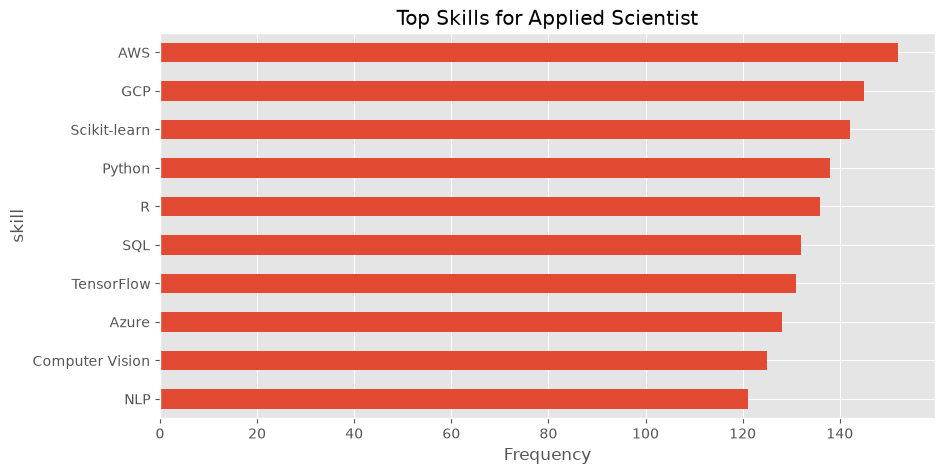

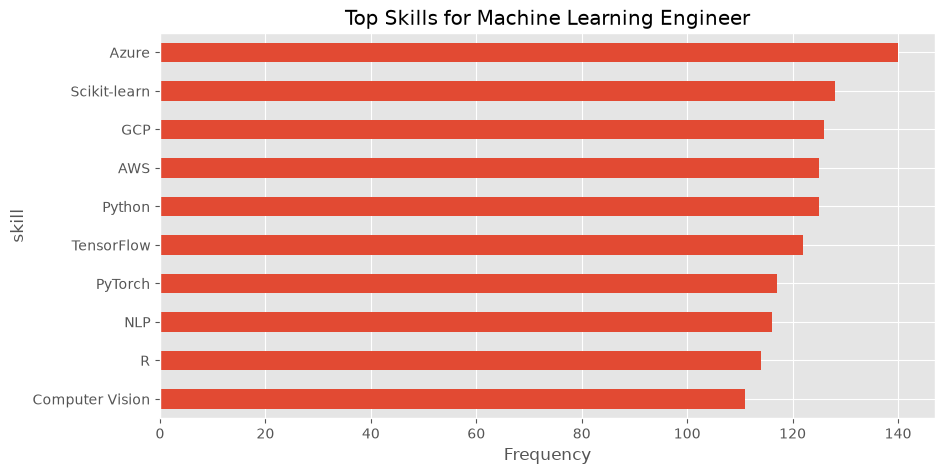

In [3]:
roles = df["job_title"].value_counts().head(10).index

for role in roles:

    plt.figure(figsize=(10,5))

    (
        df[df["job_title"] == role]["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills for {role}")
    plt.xlabel("Frequency")
    plt.show()

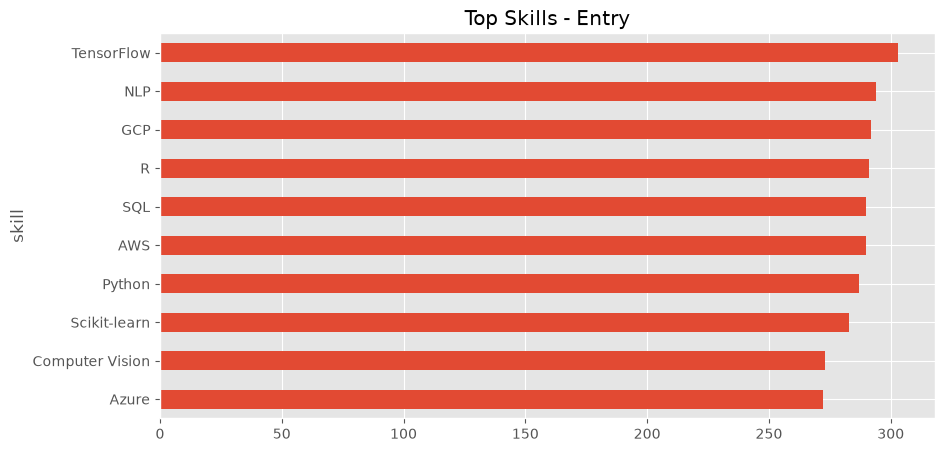

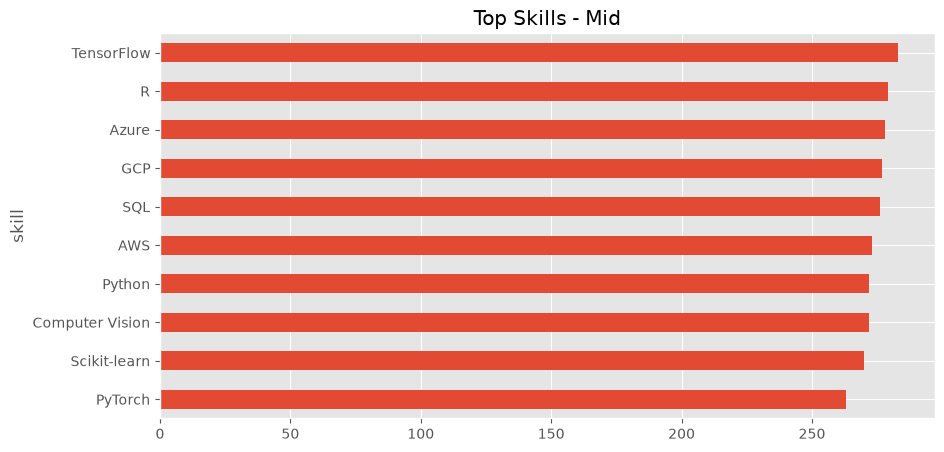

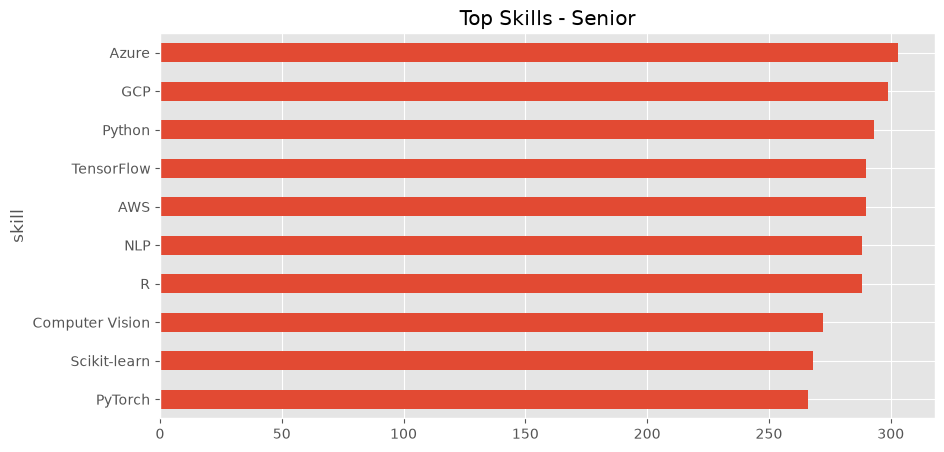

In [4]:
experience_order = [
    "Entry",
    "Mid",
    "Senior",
    "Lead",
    "Executive"
]

for level in experience_order:

    subset = df[df["experience_level"] == level]

    if subset.empty:
        continue

    plt.figure(figsize=(10,5))

    (
        subset["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(f"Top Skills - {level}")
    plt.show()

skill
Azure              112320.055686
Python             111274.002347
GCP                111141.213134
AWS                111000.444900
PyTorch            110839.628607
Computer Vision    110791.023256
R                  110729.612471
NLP                110660.401425
TensorFlow         110112.894406
Scikit-learn       109922.414738
SQL                108875.513973
Name: average_salary, dtype: float64

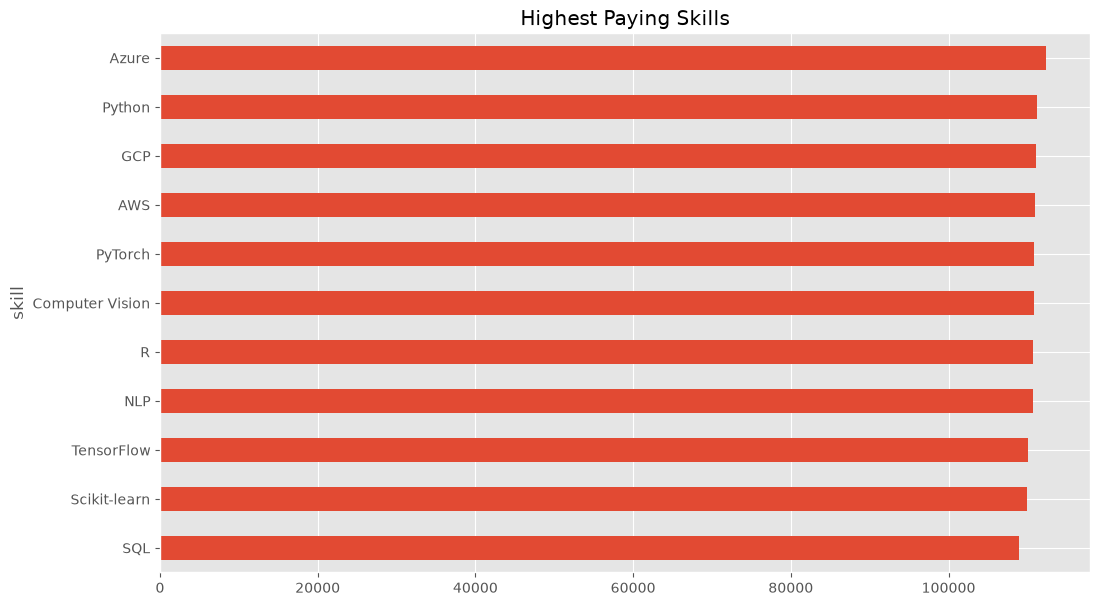

In [5]:
df["average_salary"] = (
    df["salary_min_usd"] +
    df["salary_max_usd"]
) / 2

salary_skill = (
    df.groupby("skill")["average_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

display(salary_skill)

salary_skill.sort_values().plot(
    kind="barh",
    figsize=(12,7)
)

plt.title("Highest Paying Skills")
plt.show()

job_title
Applied Scientist            111382.242167
Data Analyst                 111343.315133
Machine Learning Engineer    110816.692345
Data Scientist               110740.231570
AI Researcher                110574.632620
MLOps Engineer               110348.288541
Name: average_salary, dtype: float64

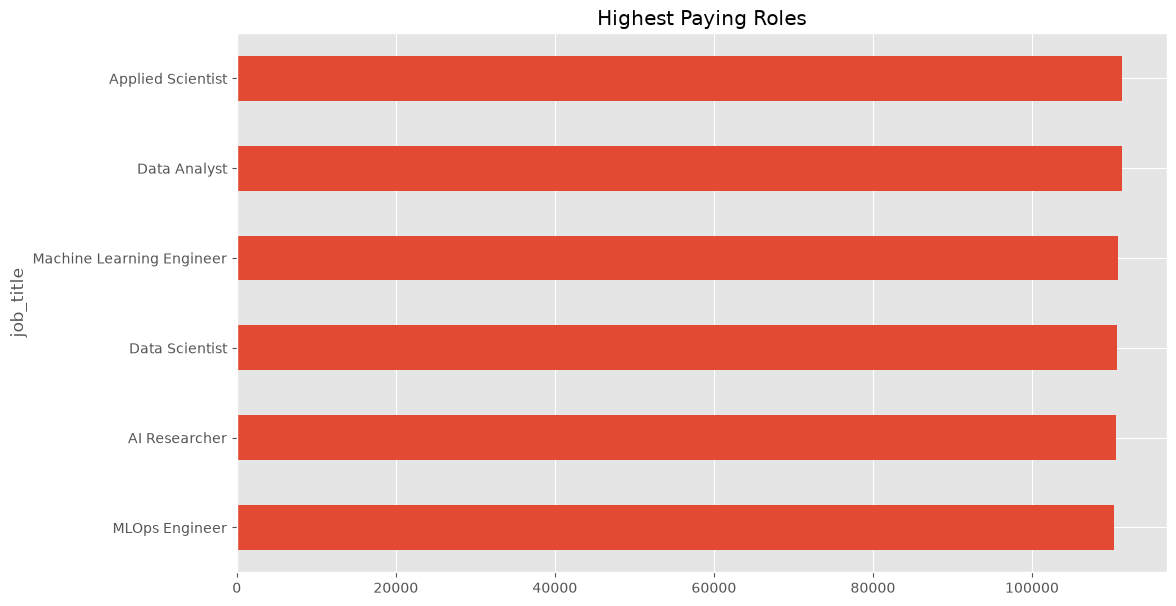

In [6]:
salary_role = (
    jobs.assign(
        average_salary=(
            jobs["salary_min_usd"] +
            jobs["salary_max_usd"]
        ) / 2
    )
    .groupby("job_title")["average_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(salary_role)

salary_role.sort_values().plot(
    kind="barh",
    figsize=(12,7)
)

plt.title("Highest Paying Roles")
plt.show()

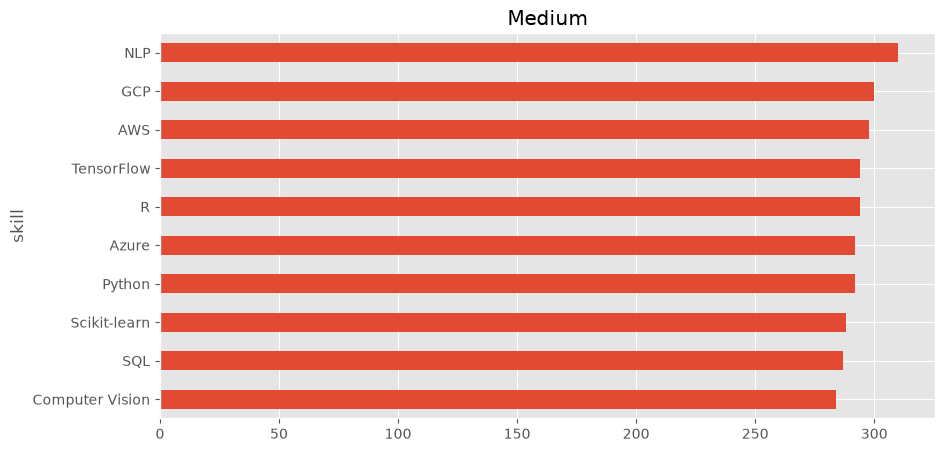

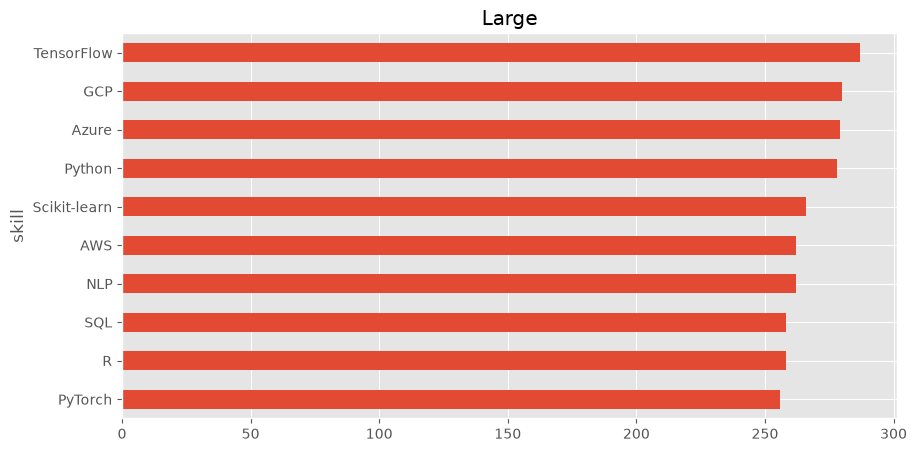

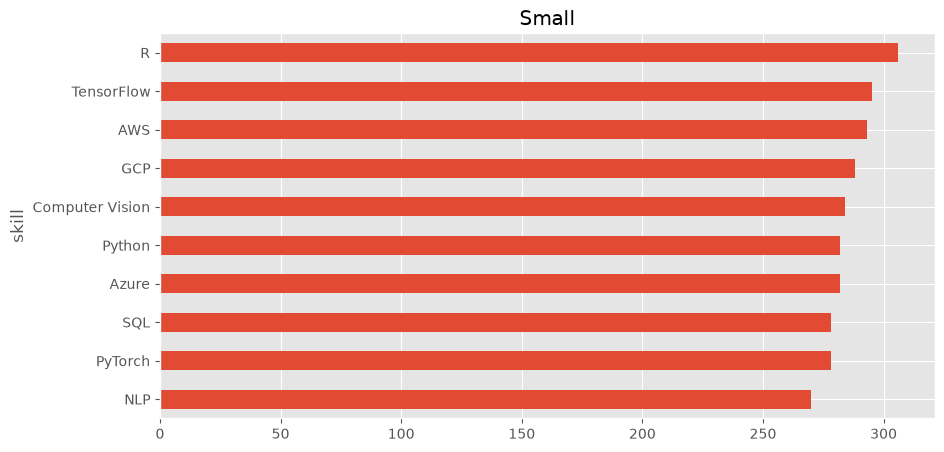

In [7]:
company_sizes = df["company_size"].unique()

for size in company_sizes:

    subset = df[df["company_size"] == size]

    plt.figure(figsize=(10,5))

    (
        subset["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(size)
    plt.show()

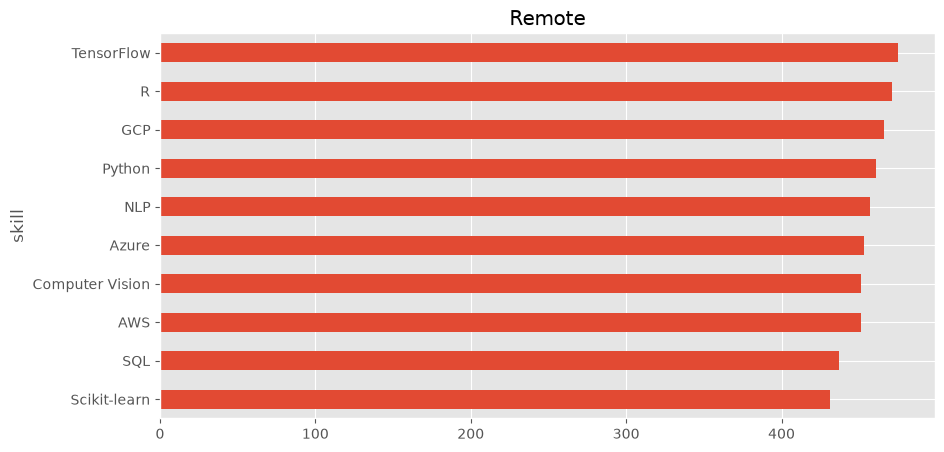

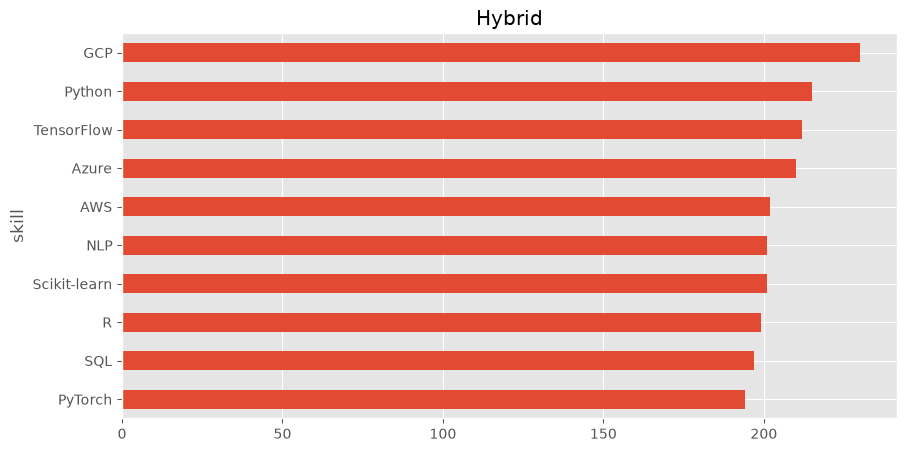

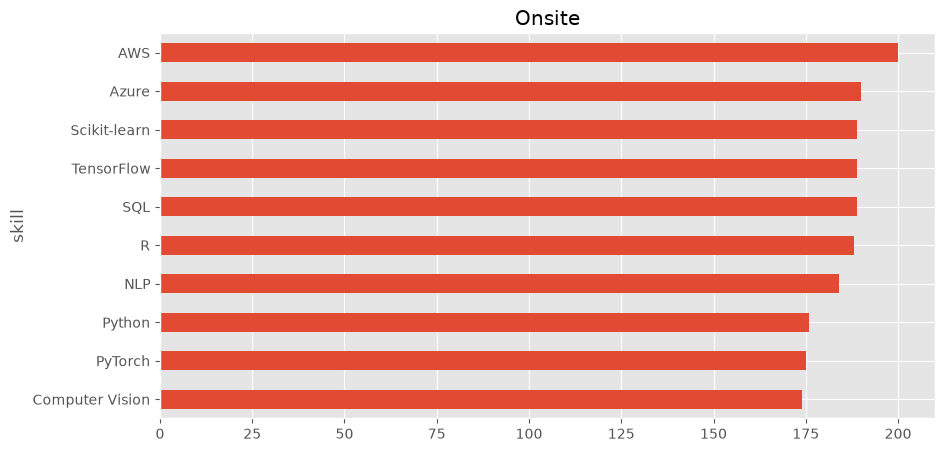

In [8]:
remote_types = df["remote_type"].unique()

for mode in remote_types:

    subset = df[df["remote_type"] == mode]

    plt.figure(figsize=(10,5))

    (
        subset["skill"]
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh")
    )

    plt.title(mode)
    plt.show()

skill_category
ML             4153
Cloud          2574
Programming    2533
Name: count, dtype: int64

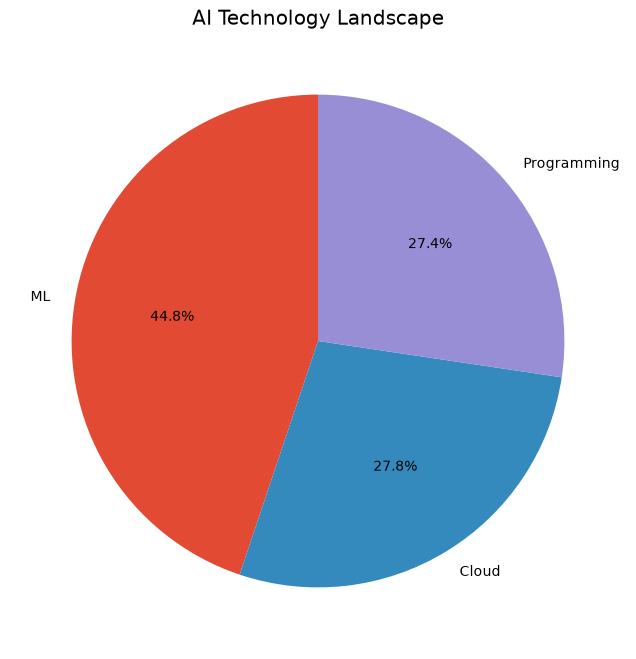

In [9]:
category = (
    df["skill_category"]
    .value_counts()
)

display(category)

plt.figure(figsize=(8,8))

plt.pie(
    category,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("AI Technology Landscape")
plt.show()

city
Remote        16478
Brisbane       1909
London         1895
Manchester     1893
Vancouver      1869
Birmingham     1868
Melbourne      1864
Sydney         1852
Montreal       1844
Toronto        1814
Frankfurt      1432
Munich         1405
Hamburg        1398
Berlin         1359
Austin         1178
Name: count, dtype: int64

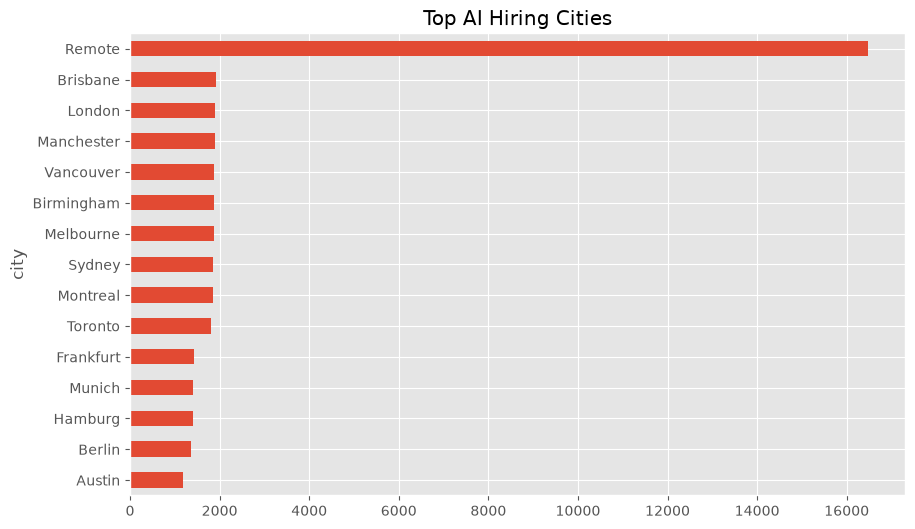

In [10]:
top_cities = jobs["city"].value_counts().head(15)

display(top_cities)

top_cities.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top AI Hiring Cities")
plt.show()

industry
Tech          10083
Healthcare    10029
Retail         9979
Finance        9970
Education      9939
Name: count, dtype: int64

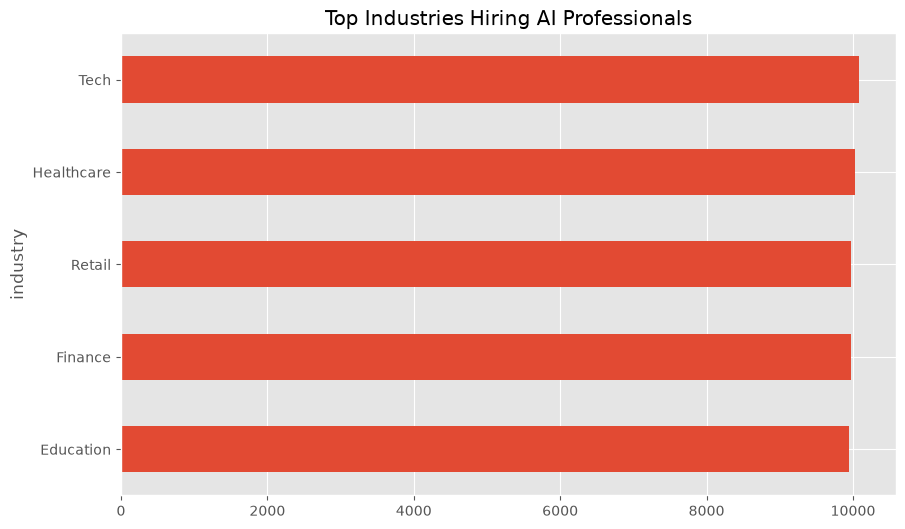

In [11]:
industry = jobs["industry"].value_counts().head(15)

display(industry)

industry.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Industries Hiring AI Professionals")
plt.show()

In [12]:
print("="*60)
print("AI JOB MARKET INSIGHTS")
print("="*60)

print(f"\nTotal Jobs: {len(jobs):,}")
print(f"Total Skills: {len(skills):,}")
print(f"Countries: {jobs['country'].nunique()}")
print(f"Cities: {jobs['city'].nunique()}")

print("\nTop Role:")
print(jobs["job_title"].value_counts().head(1))

print("\nTop Skill:")
print(skills["skill"].value_counts().head(1))

print("\nTop Country:")
print(jobs["country"].value_counts().head(1))

AI JOB MARKET INSIGHTS

Total Jobs: 50,000
Total Skills: 224,605
Countries: 6
Cities: 24

Top Role:
job_title
MLOps Engineer    8439
Name: count, dtype: int64

Top Skill:
skill
AWS    20638
Name: count, dtype: int64

Top Country:
country
UK    8452
Name: count, dtype: int64
